In [44]:
import pandas as pd
from modelens import ClassificationAnalyzer, classification_models

In [45]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

In [46]:
raw_data = fetch_openml(
    name="banknote-authentication",
    as_frame=True,
)

data = raw_data.frame

df = data.copy()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset.csv'

In [ ]:
df = df.rename(
    columns={
        "V1": "variance",
        "V2": "skewness",
        "V3": "curtosis",
        "V4": "entropy",
        "Class": "class",
    }
)
df["class"] = (
    df["class"]
    .map(
        {
            "1": 0,
            "2": 1,
        }
    )
    .astype(int)
)

In [ ]:
analyzer = ClassificationAnalyzer(df, target="class")

#### 1 - EDA + ETL

In [ ]:
analyzer.info()

In [ ]:
df = df.drop_duplicates()

In [ ]:
analyzer.reinit(df, "class")

In [ ]:
# Check Invalid Data
analyzer.info()

In [ ]:
analyzer.reinit(df=df, target="class")

In [ ]:
df.head()

#### 2 - Comparing Models

In [ ]:
target = "class"
X = df.drop(columns=[target])
y = df[target]
features = df.columns.drop(target)

In [ ]:
analyzer.correlation()

In [ ]:
analyzer.vif()

In [ ]:
analyzer.permutation_importance()

In [ ]:
# analyzer.evaluate_single_feature_removal(
#     model=model,
#     features=features,
#     export_html=True,
#     file_name="knn",
# )

In [ ]:
# analyzer.evaluate_feature_removal_combinations(
#     model=model,
#     features=features,
#     candidates=features,
#     export_html=True,
#     file_name="knn",
# )

In [ ]:
# selected_models = classification_models()
# analyzer.compare_models(
#     models=selected_models,
#     features=features,
#     export_html=True,
#     file_name="01-all-models",
# )

In [ ]:
from sklearn.tree import DecisionTreeClassifier

selected_model = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy", "log_loss"],
    "class_weight": [None, "balanced"],
}
# analyzer.tune_model(
#     model=selected_model,
#     features=features,
#     param_grid=param_grid,
#     export_html=True,
#     file_name="decision_tree",
# )

In [ ]:
analyzer.evaluate_single_feature_removal(
    model=selected_model,
    features=features,
    export_html=True,
    file_name="decision_tree",
)
# Remove entropy
remove_features = ["entropy"]

In [ ]:
# analyzer.evaluate_feature_removal_combinations(
#     model=selected_model,
#     features=features,
#     candidates=features,
#     export_html=True,
#     file_name="decision_tree",
# )
# Remove just entropy

In [ ]:
optimized_features = features.drop(remove_features)

analyzer.compare_feature_sets(
    model=selected_model,
    feature_sets={
        "All Features": features,
        "Optimized Features": optimized_features,
    },
)

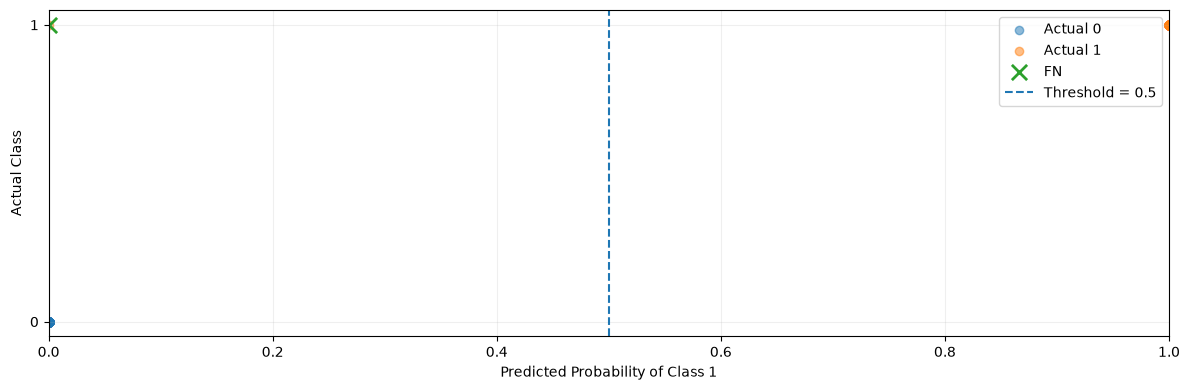

(      variance  skewness  curtosis  Actual  Predicted  Probability  Confidence
 1246   -2.4561   -4.5566    6.4534       1          0          0.0         1.0,
           FN Mean   TP Mean  Difference
 variance  -2.4561 -2.174920   -0.281180
 skewness  -4.5566 -0.749071   -3.807529
 curtosis   6.4534  2.235139    4.218261)

In [40]:
analyzer.analyze_prediction_group(model=selected_model, features=optimized_features)

In [ ]:
analyzer.evaluate_thresholds(model=selected_model, features=optimized_features)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)

cm_df

,Predicted 0,Predicted 1
Actual 0,148,0
Actual 1,1,121
